In [1]:
import sys
import socket

print(f"Node:{socket.gethostname()}")


Node:c023.curta.zedat.fu-berlin.de


In [2]:
from pyproj import Transformer

import duckdb
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from pathlib import Path
import duckdb


from photometry.models.hapke import HapkeModel
from photometry.core.types import GeometryBatch
from photometry.fitting.least_sq import LeastSquaresFitter

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS



In [3]:


project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent


# Load the RC Parquet file

parquet_path_hamo_dsk256_110825 = project_root / "data" / "silver/dsk256" / "hamo_dsk256_110825.parquet"

parquet_path_survey_binned_phase_curves_range50 = project_root / "data" / "golden" / "survey_binned_dsk256_110825_range50.parquet"




In [4]:
vesta_user_crs = ("+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=180 "
                   "+x_0=0 +y_0=0 +R=255000 +units=m +no_defs +type=crs")
vesta_iau_crs  = "+proj=longlat +R=255000 +no_defs"

transformer = Transformer.from_crs(vesta_user_crs, vesta_iau_crs, always_xy=True)

regions_m = {
    "oppia_ejecta_orange": [
        (558714.502, -55962.360), (559476.111, -70242.536),
        (585370.830, -70813.743), (584799.623, -56343.165),
    ],
    "oppia_orange_patch": [
        (607769.687, 7328.694), (609829.494, 2542.672),
        (616735.906, 2603.254), (615827.168, 8419.181),
    ],
    "oppia_surrounding": [
        (630548.731, 11508.891), (631396.886, 1331.021),
        (648238.839, 1815.681), (647633.014, 12599.377),
    ],
}

roi_bounds = {}
for name, corners in regions_m.items():
    xs, ys = zip(*corners)
    lons, lats = transformer.transform(np.array(xs), np.array(ys))
    roi_bounds[name] = {
        "lon_min": lons.min(), "lon_max": lons.max(),
        "lat_min": lats.min(), "lat_max": lats.max(),
    }
    print(name, roi_bounds[name])

oppia_ejecta_orange {'lon_min': np.float64(-54.46281208880943), 'lon_max': np.float64(-48.4734195722745), 'lat_min': np.float64(-15.911092570290498), 'lat_max': np.float64(-12.574145253300932)}
oppia_orange_patch {'lon_min': np.float64(-43.44063536828608), 'lon_max': np.float64(-41.426021615776186), 'lat_min': np.float64(0.5713112717101492), 'lat_max': np.float64(1.8917001500264)}
oppia_surrounding {'lon_min': np.float64(-38.32242720145156), 'lon_max': np.float64(-34.34764866211577), 'lat_min': np.float64(0.2990662186011072), 'lat_max': np.float64(2.830945594487061)}


In [5]:
for name, b in roi_bounds.items():
    roi_hamo = duckdb.sql(f"""
        SELECT COUNT(*) as n
        FROM read_parquet('{parquet_path_hamo_dsk256_110825}')
        WHERE longitude BETWEEN {b['lon_min']} AND {b['lon_max']}
          AND latitude  BETWEEN {b['lat_min']} AND {b['lat_max']}
          AND iof > 0.01 AND image_id LIKE '%F1B%'
    """).fetchone()
    print(name, roi_hamo[0], "HAMO pixels")

oppia_ejecta_orange 448047 HAMO pixels
oppia_orange_patch 60644 HAMO pixels
oppia_surrounding 268687 HAMO pixels


In [6]:
for name, b in roi_bounds.items():
    stats = duckdb.sql(f"""
        SELECT
            COUNT(*) AS n,
            COUNT(DISTINCT image_id) AS n_images,
            MIN(phase) AS phase_min,
            MAX(phase) AS phase_max,
            AVG(incidence) AS mean_inc,
            AVG(emission) AS mean_emi
        FROM read_parquet('{parquet_path_hamo_dsk256_110825}')
        WHERE longitude BETWEEN {b['lon_min']} AND {b['lon_max']}
          AND latitude  BETWEEN {b['lat_min']} AND {b['lat_max']}
          AND iof > 0.0156 * COS(RADIANS(incidence))
          AND image_id LIKE '%F1B%'
    """).fetchone()
    print(name, stats)

oppia_ejecta_orange (448047, 7, 32.06801986694336, 59.020668029785156, 36.01082194793046, 18.22753673157136)
oppia_orange_patch (60644, 5, 32.50377655029297, 43.87208938598633, 32.84350235205387, 22.01268848826452)
oppia_surrounding (268687, 8, 30.786304473876953, 52.515846252441406, 25.96842093264989, 19.09825297281917)


In [ ]:
import duckdb

    try:
      duckdb
    except NameError:

    image_list = duckdb.sql(f"""
      SELECT image_id, COUNT(*) AS pixel_count
      FROM read_parquet('{parquet_path_hamo_dsk256_110825}')
      WHERE longitude BETWEEN {b['lon_min']} AND {b['lon_max']}
        AND latitude  BETWEEN {b['lat_min']} AND {b['lat_max']}
        AND iof > 0.0156 * COS(RADIANS(incidence))
        AND image_id LIKE '%F1B%'
      GROUP BY image_id
      ORDER BY pixel_count DESC
    """).df()

    print(image_list.to_string(index=False))
    print(image_list.to_string(index=False))
  

                   image_id  pixel_count
FC21B0027481_12178091553F1B        61327
FC21B0027482_12178092153F1B        50646
FC21B0028953_12193181042F1B        49678
FC21B0028952_12193180442F1B        48668
FC21B0027345_12176200034F1B        40066
FC21B0027344_12176195434F1B        11108
FC21B0028954_12193181642F1B         6542
FC21B0029093_12195073122F1B          652


In [7]:
model = HapkeModel(
    enable_shoe=True, enable_roughness=True,
    fixed_parameters={'B0': 1.03, 'h': 0.04}
)
model.parameters.update({'w': 0.4656, 'g': -0.3325, 'theta_bar': 8.38})

# their exact CRS, for writing output back in their coordinate system
vesta_user_crs = CRS.from_proj4(
    "+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=180 "
    "+x_0=0 +y_0=0 +R=255000 +units=m +no_defs"
)

In [8]:
def correct_and_export_region_wide(name, lon_min, lon_max, lat_min, lat_max,
                                     x_min, x_max, y_min, y_max,
                                     parquet_path, out_path, grid_res_m=20):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    df = duckdb.sql(f"""
        SELECT pixel_x, pixel_y, iof, incidence, emission, phase,
               latitude, longitude
        FROM read_parquet('{parquet_path}')
        WHERE longitude BETWEEN {lon_min} AND {lon_max}
          AND latitude  BETWEEN {lat_min} AND {lat_max}
          AND incidence < 50.0
          AND emission < 50.0
          AND iof > 0.0156 * COS(RADIANS(incidence))
          AND image_id LIKE '%F1B%'
    """).df()

    n_images = df['image_id'].nunique() if 'image_id' in df.columns else None
    print(f"{name}: {len(df):,} pixels, "
          f"phase {df['phase'].min():.1f}–{df['phase'].max():.1f}°"
          + (f", {n_images} images" if n_images else ""))

    geom = GeometryBatch(
        incidence=np.deg2rad(df['incidence'].to_numpy()),
        emission=np.deg2rad(df['emission'].to_numpy()),
        phase=np.deg2rad(df['phase'].to_numpy())
    )
    geom_std = GeometryBatch(
        incidence=np.deg2rad(np.full(len(df), 30.0)),
        emission=np.deg2rad(np.zeros(len(df))),
        phase=np.deg2rad(np.full(len(df), 30.0))
    )
    pred_real = model._reflectance_numpy(geom)
    pred_std  = model._reflectance_numpy(geom_std)
    correction = np.clip(pred_std / np.maximum(pred_real, 1e-6), 0.5, 2.5)
    df['iof_corrected'] = df['iof'].to_numpy() * correction

    n_lat = int((lat_max - lat_min) * 111000 / grid_res_m)
    n_lon = int((lon_max - lon_min) * 111000 *
                np.cos(np.deg2rad((lat_min+lat_max)/2)) / grid_res_m)
    n_lat, n_lon = max(n_lat, 10), max(n_lon, 10)

    from scipy.stats import binned_statistic_2d
    grid, _, _, _ = binned_statistic_2d(
        df['latitude'], df['longitude'], df['iof_corrected'],
        statistic='mean', bins=[n_lat, n_lon],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    grid = np.flipud(grid)

    transform = from_bounds(x_min, y_min, x_max, y_max, n_lon, n_lat)
    with rasterio.open(
        out_path, "w", driver="GTiff",
        height=n_lat, width=n_lon, count=1,
        dtype="float32", crs=vesta_user_crs, transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(grid.astype("float32"), 1)
    print(f"  → wrote {out_path}")
    return df, grid

In [12]:
Path("results_tif").mkdir(parents=True, exist_ok=True)

## Region 1

In [13]:
r1_df, r1_grid = correct_and_export_region_wide(
    "oppia_ejecta_orange",
    lon_min=roi_bounds['oppia_ejecta_orange']['lon_min'],
    lon_max=roi_bounds['oppia_ejecta_orange']['lon_max'],
    lat_min=roi_bounds['oppia_ejecta_orange']['lat_min'],
    lat_max=roi_bounds['oppia_ejecta_orange']['lat_max'],
    x_min=558714.502, x_max=585370.830,
    y_min=-70813.743, y_max=-55962.360,
    parquet_path=str(parquet_path_hamo_dsk256_110825),  
    out_path="results_tif/roi_oppia_ejecta_orange_hamo.tif"
)


oppia_ejecta_orange: 447,952 pixels, phase 32.1–59.0°
  → wrote results_tif/roi_oppia_ejecta_orange_hamo.tif


## Region 2

In [14]:
r2_df, r2_grid = correct_and_export_region_wide(
    "oppia_orange_patch",
    lon_min=roi_bounds['oppia_orange_patch']['lon_min'],
    lon_max=roi_bounds['oppia_orange_patch']['lon_max'],
    lat_min=roi_bounds['oppia_orange_patch']['lat_min'],
    lat_max=roi_bounds['oppia_orange_patch']['lat_max'],
    x_min=607769.687, x_max=616735.906,
    y_min=2542.672, y_max=8419.181,
    parquet_path=str(parquet_path_hamo_dsk256_110825),  
    out_path="results_tif/roi_oppia_orange_patch_hamo.tif"
)


oppia_orange_patch: 60,644 pixels, phase 32.5–43.9°
  → wrote results_tif/roi_oppia_orange_patch_hamo.tif


## Region 3

In [16]:
r3_df, r3_grid = correct_and_export_region_wide(
    "oppia_surrounding",
    lon_min=roi_bounds['oppia_surrounding']['lon_min'],
    lon_max=roi_bounds['oppia_surrounding']['lon_max'],
    lat_min=roi_bounds['oppia_surrounding']['lat_min'],
    lat_max=roi_bounds['oppia_surrounding']['lat_max'],
    x_min=630548.731, x_max=648238.839,
    y_min=1331.021, y_max=12599.377,
    parquet_path=str(parquet_path_hamo_dsk256_110825),  
    out_path="results_tif/roi_oppia_surrounding_hamo.tif"
)




oppia_surrounding: 268,499 pixels, phase 30.8–52.5°
  → wrote results_tif/roi_oppia_surrounding_hamo.tif


## Phase curves 

In [18]:
df_global = pd.read_parquet(parquet_path_survey_binned_phase_curves_range50)
global_phase = df_global['mean_phase'].to_numpy()
global_iof   = df_global['mean_iof'].to_numpy()

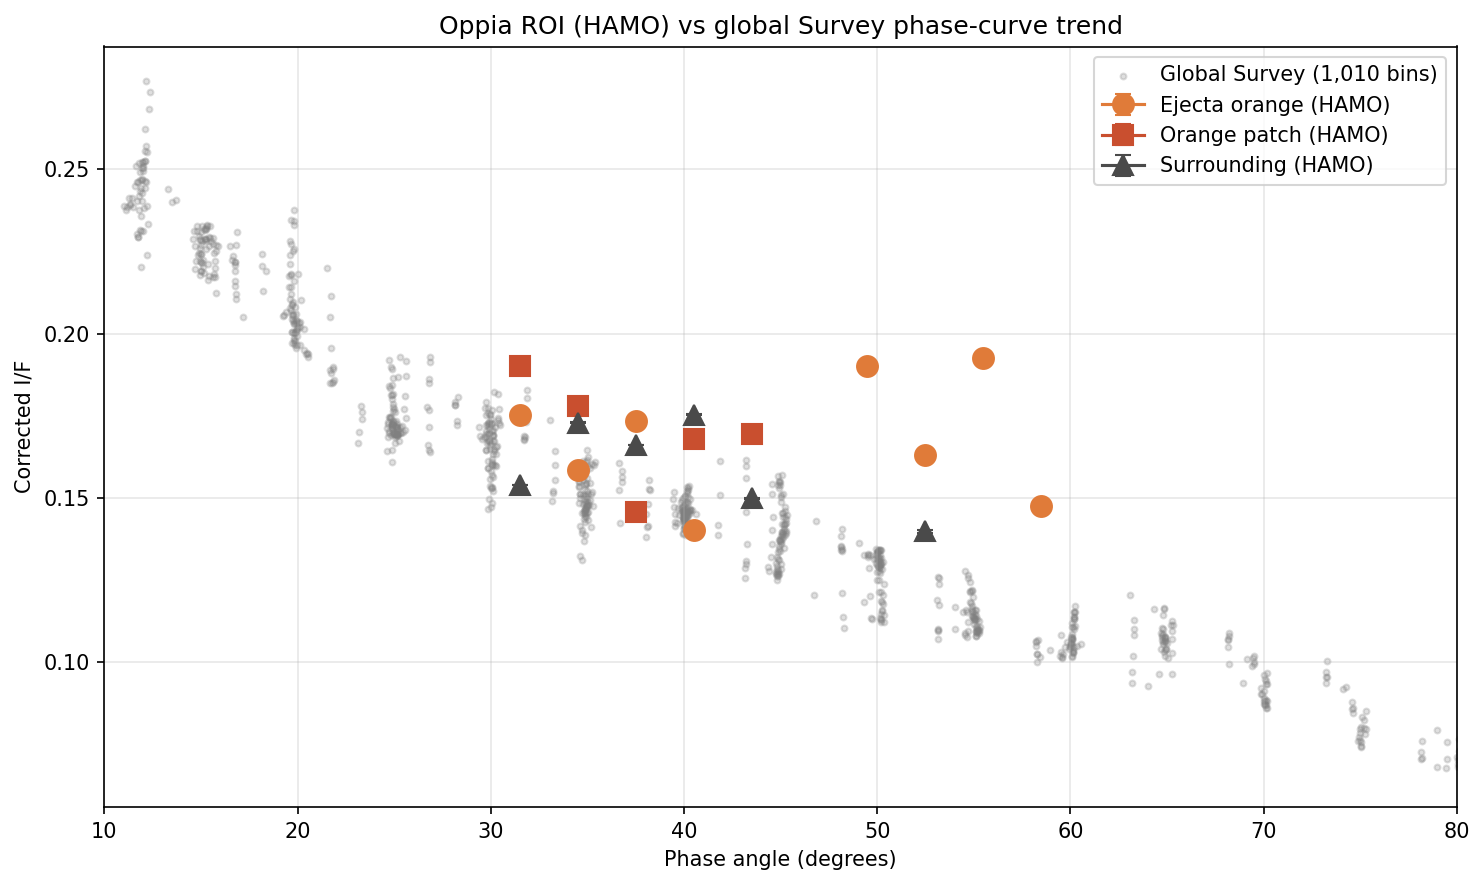

In [28]:

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.scatter(global_phase, global_iof, s=8, alpha=0.25, color='gray',
           label='Global Survey (1,010 bins)')

regions_hamo = [
    ("Ejecta orange (HAMO)", r1_df, '#e07b39', 'o'),
    ("Orange patch (HAMO)",  r2_df, '#c94f2f', 's'),
    ("Surrounding (HAMO)",   r3_df, '#4a4a4a', '^'),
]

for name, df, color, marker in regions_hamo:
    bins = np.arange(df['phase'].min()//3*3, df['phase'].max()+3, 3)
    first = True
    for b in bins[:-1]:
        mask = (df['phase'] >= b) & (df['phase'] < b+3)
        if mask.sum() < 5:
            continue
        mean_iof = df.loc[mask, 'iof_corrected'].mean()
        se = df.loc[mask, 'iof_corrected'].std() / np.sqrt(mask.sum())
        phase_c = b + 1.5
        ax.errorbar(phase_c, mean_iof, yerr=se, marker=marker, ms=10,
                    color=color, capsize=4, elinewidth=1.5,
                    label=name if first else None)
        first = False

ax.set_xlim(10, 80)

ax.set_xlabel('Phase angle (degrees)')
ax.set_ylabel('Corrected I/F')
ax.set_title('Oppia ROI (HAMO) vs global Survey phase-curve trend')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('results/oppia_roi_hamo_vs_global_overlay.png', dpi=150)
plt.show()

## HAMO phase binnng 

In [20]:
# Maximize the 32GB SLURM node
duckdb.sql("PRAGMA threads=8;")
duckdb.sql("PRAGMA memory_limit='28GB';")


# Paths

golden_path = Path("data/golden/hamo_binned_dsk256_110825_range50.parquet")
golden_path.parent.mkdir(parents=True, exist_ok=True)


binned_hamo_dsk256_lt50_query = f"""

SELECT 
    -- 1. Banker's Rounding with Float-Safe Epsilon (< 1e-9)

    (CASE 
        WHEN ABS((phase/5.0) - FLOOR(phase/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(phase/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(phase/5.0) ELSE CEIL(phase/5.0) END)
        ELSE ROUND(phase/5.0) 
    END) * 5.0 AS alpha_grid,
    
    (CASE 
        WHEN ABS((incidence/5.0) - FLOOR(incidence/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(incidence/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(incidence/5.0) ELSE CEIL(incidence/5.0) END)
        ELSE ROUND(incidence/5.0) 
    END) * 5.0 AS i_grid,
    
    (CASE 
        WHEN ABS((emission/5.0) - FLOOR(emission/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(emission/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(emission/5.0) ELSE CEIL(emission/5.0) END)
        ELSE ROUND(emission/5.0) 
    END) * 5.0 AS e_grid,
    
    -- 2. Target Aggregations

    AVG(incidence) AS mean_incidence,
    AVG(emission) AS mean_emission,
    AVG(phase) AS mean_phase,
    AVG(iof) AS mean_iof,
    STDDEV_SAMP(iof) AS std_iof,
    COUNT(*) AS n_pixels

FROM read_parquet('{parquet_path_hamo_dsk256_110825}')

-- 3. The Physical Boundary Restored (Triangle Law)

WHERE incidence < 50.0
  AND emission < 50.0
  -- AND iof > 0.01
  AND image_id LIKE '%F1B%'
  AND phase >= ABS(incidence - emission)       
  AND phase <= (incidence + emission) + 0.1

GROUP BY 1, 2, 3

-- 4. Statistical Validity Check

HAVING COUNT(*) >= 10 
   AND STDDEV_SAMP(iof) IS NOT NULL

ORDER BY 1, 2, 3

"""


# Execute the query and pull the tiny result table into Python RAM

df_binned_hamo_dsk256_lt50 = duckdb.sql(binned_hamo_dsk256_lt50_query).df()

print(f"DuckDB binning complete. Retained {len(df_binned_hamo_dsk256_lt50):,} safe geometric cubes.")

# Save the GL so you never have to do this again

df_binned_hamo_dsk256_lt50.to_parquet(golden_path, index=False)
print(f"Saved GL to: {golden_path}")
display(df_binned_hamo_dsk256_lt50)



DuckDB binning complete. Retained 851 safe geometric cubes.
Saved GL to: data/golden/hamo_binned_dsk256_110825_range50.parquet


,alpha_grid,i_grid,e_grid,mean_incidence,mean_emission,mean_phase,mean_iof,std_iof,n_pixels
0,20.0,5.0,15.0,6.840083,16.192815,22.156057,0.206057,0.017801,1324
1,20.0,5.0,20.0,6.602295,19.320776,22.241654,0.210144,0.017344,1116
2,20.0,5.0,25.0,6.877475,22.903335,22.472809,0.236375,0.004799,24
3,20.0,10.0,10.0,11.468491,11.154682,21.867950,0.203270,0.018482,10514
4,20.0,10.0,15.0,10.300725,14.748660,21.991095,0.208712,0.019207,18657
...,...,...,...,...,...,...,...,...,...
846,95.0,45.0,45.0,46.740143,46.758746,93.076610,0.059204,0.028144,21939
847,95.0,45.0,50.0,45.773601,48.897509,93.923853,0.065894,0.030155,72866
848,95.0,50.0,45.0,49.015079,45.705324,94.020357,0.057816,0.026256,87421
849,95.0,50.0,50.0,48.634180,48.673101,95.632286,0.061431,0.027381,58759


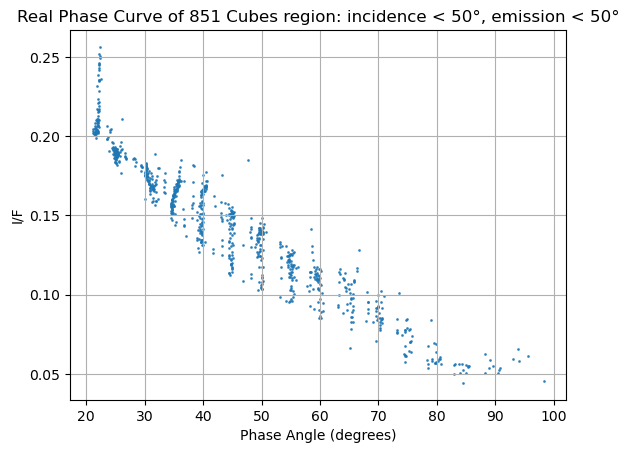

In [21]:

plt.scatter(df_binned_hamo_dsk256_lt50["mean_phase"], df_binned_hamo_dsk256_lt50["mean_iof"], alpha=0.8, s=1)
plt.title(f"Real Phase Curve of {len(df_binned_hamo_dsk256_lt50):,} Cubes region: incidence < 50°, emission < 50°")
plt.xlabel("Phase Angle (degrees)")
plt.ylabel("I/F")
plt.grid(True)
plt.show()

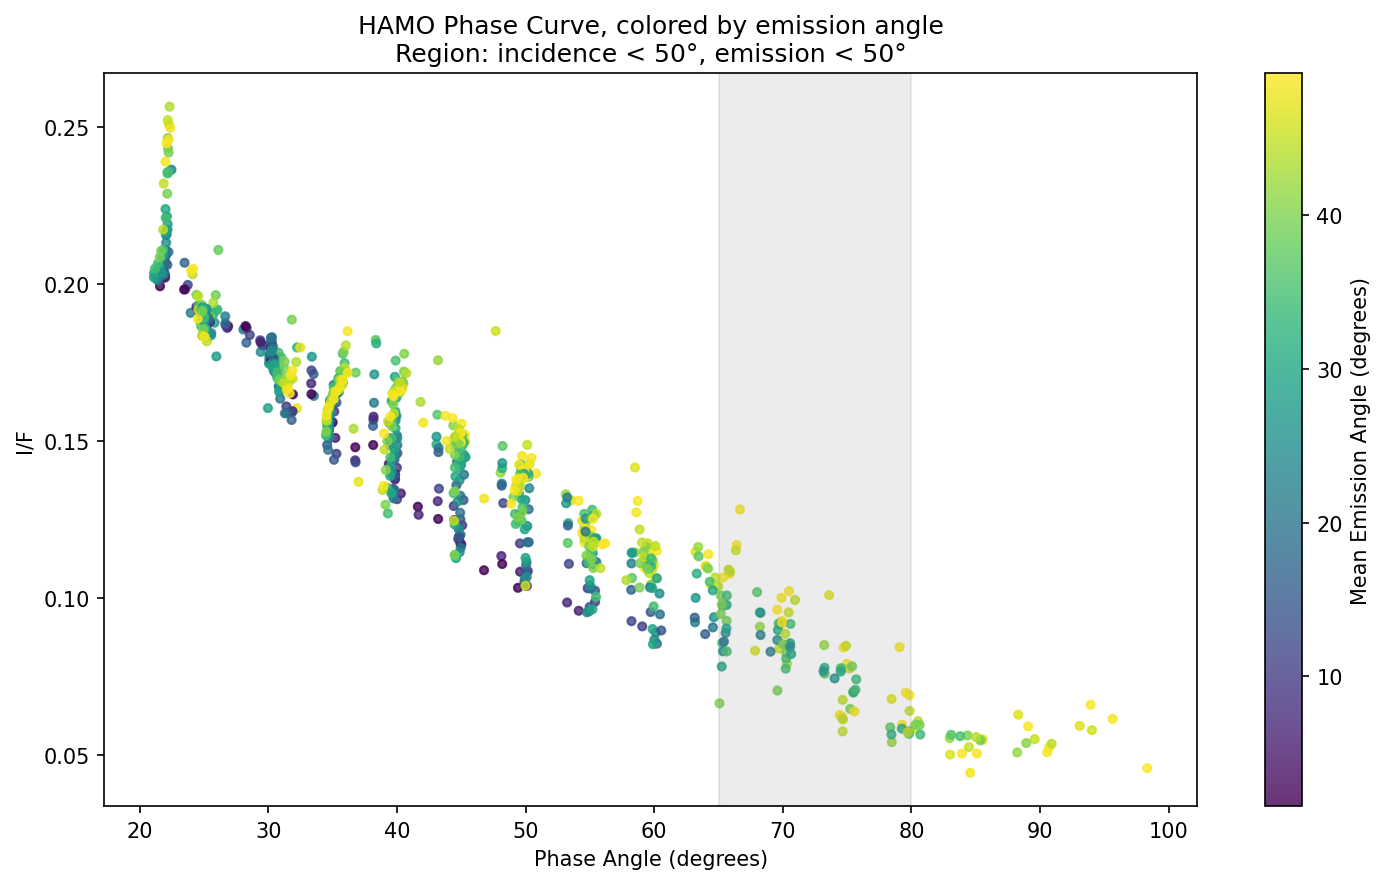

In [26]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sc = ax.scatter(df_binned_hamo_dsk256_lt50['mean_phase'], df_binned_hamo_dsk256_lt50['mean_iof'],
                 c=df_binned_hamo_dsk256_lt50['mean_emission'], cmap='viridis',
                 s=15, alpha=0.8)
plt.colorbar(sc, label='Mean Emission Angle (degrees)')
#ax.set_xlim(0, 80)
ax.axvspan(65, 80, color='gray', alpha=0.15)
ax.set_xlabel('Phase Angle (degrees)')
ax.set_ylabel('I/F')
ax.set_title('HAMO Phase Curve, colored by emission angle\n'
             'Region: incidence < 50°, emission < 50°')
plt.tight_layout()
plt.show()